In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
#spalten
df = pd.read_csv("AmesHousing.csv")

In [72]:
# erste 5 Zeilen ansehen
print(df.head())

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePrice  
0       

In [73]:
# Anzahl Zeilen und Spalten ansehen
print(df.shape)

(2930, 82)


In [74]:
# Spaltennamen ansehen
print(df.columns)

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [75]:
# Datentypen und fehlende Werte ansehen
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [76]:
# nur numerische Spalten auswählen
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Korrelationen mit SalePrice berechnen und sortieren
corr_with_price = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

print(corr_with_price)

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647877
Garage Area        0.640401
Total Bsmt SF      0.632280
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Garage Yr Blt      0.526965
Mas Vnr Area       0.508285
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.432914
Lot Frontage       0.357318
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.276050
2nd Flr SF         0.269373
Lot Area           0.266549
Bsmt Unf SF        0.182855
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.005891
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035835
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

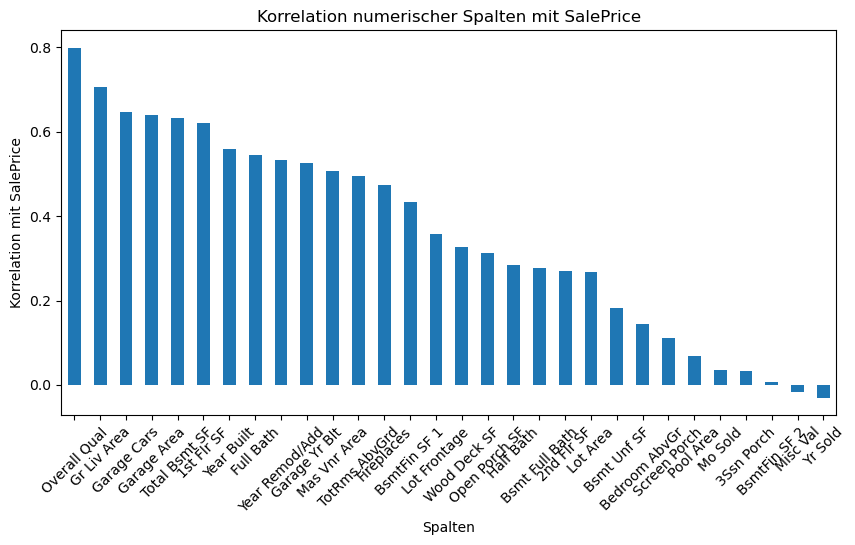

In [77]:
# die wichtigsten Korrelationen mit SalePrice als Balkendiagramm anzeigen
corr_plot = corr_with_price.drop('SalePrice').head(30)

corr_plot.plot(kind='bar', figsize=(10, 5))

plt.title('Korrelation numerischer Spalten mit SalePrice')
plt.xlabel('Spalten')
plt.ylabel('Korrelation mit SalePrice')
plt.xticks(rotation=45)
plt.show()

In [78]:
# diese numerischen Spalten aus dem Datensatz löschen
df = df.drop(columns=[
    'BsmtFin SF 1',
    'Lot Frontage',
    'Wood Deck SF',
    'Open Porch SF',
    'Half Bath',
    'Bsmt Full Bath',
    '2nd Flr SF',
    'Lot Area',
    'Bsmt Unf SF',
    'Bedroom AbvGr',
    'Screen Porch',
    'Pool Area',
    'Mo Sold',
    '3Ssn Porch',
    'BsmtFin SF 2',
    'Misc Val',
    'Yr Sold',
    'Order',
    'Bsmt Half Bath',
    'Low Qual Fin SF',
    'MS SubClass',
    'Overall Cond',
    'Kitchen AbvGr',
    'Enclosed Porch',
    'PID'
])

In [79]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Korrelationen mit SalePrice berechnen und sortieren
corr_with_price = numeric_df.corr()['SalePrice'].sort_values(ascending=False)

print(corr_with_price)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
Name: SalePrice, dtype: float64


In [80]:
# alle kategorialen Spalten auswählen
categorical_cols = df.select_dtypes(include=['object']).columns

cat_results = []

for col in categorical_cols:
    grouped = df.groupby(col)['SalePrice']
    means = grouped.mean()
    counts = grouped.size()
    
    cat_results.append({
        'Spalte': col,
        'Anzahl_Kategorien': df[col].nunique(),
        'Kleinste_Gruppe': counts.min(),
        'Groesste_Gruppe': counts.max(),
        'Min_Durchschnittspreis': round(means.min(), 0),
        'Max_Durchschnittspreis': round(means.max(), 0),
        'Differenz': round(means.max() - means.min(), 0),
        'Std_der_Gruppenmittel': round(means.std(), 0)
    })

cat_results_df = pd.DataFrame(cat_results).sort_values(
    by=['Std_der_Gruppenmittel', 'Differenz'],
    ascending=False
)

print(cat_results_df)

            Spalte  Anzahl_Kategorien  Kleinste_Gruppe  Groesste_Gruppe  \
38         Pool QC                  4                2                4   
18      Exter Qual                  4               35             1799   
10     Condition 2                  8                1             2900   
21       Bsmt Qual                  5                2             1283   
30    Kitchen Qual                  5                1             1494   
17    Mas Vnr Type                  4                1              880   
32    Fireplace Qu                  5               43              744   
14       Roof Matl                  8                1             2887   
35     Garage Qual                  5                3             2615   
8     Neighborhood                 28                1              443   
0        MS Zoning                  7                2             2273   
28     Central Air                  2              196             2734   
16    Exterior 2nd       

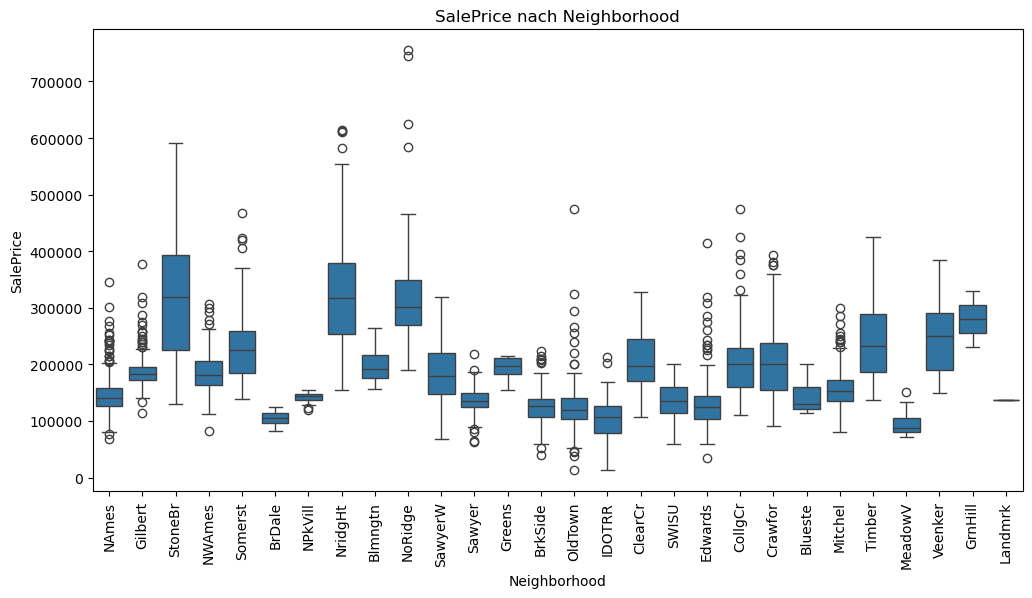

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot: SalePrice nach Neighborhood
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="Neighborhood", y="SalePrice")
plt.xticks(rotation=90)
plt.title("SalePrice nach Neighborhood")
plt.show()
#behalten

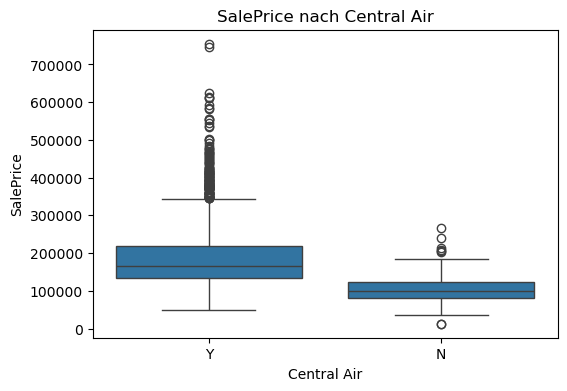

In [82]:
# Boxplot: SalePrice nach Central Air
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Central Air", y="SalePrice")
plt.title("SalePrice nach Central Air")
plt.show()
#behalten

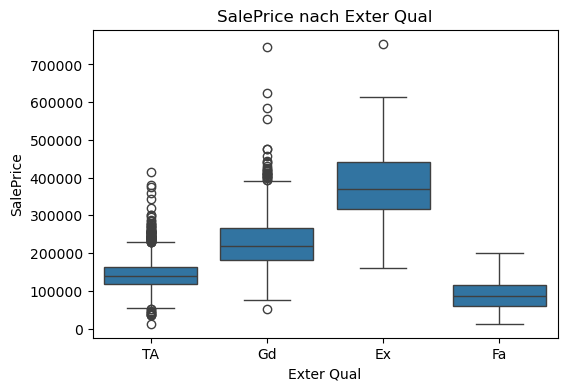

In [83]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Exter Qual", y="SalePrice")
plt.title("SalePrice nach Exter Qual")
plt.show()
#behalten

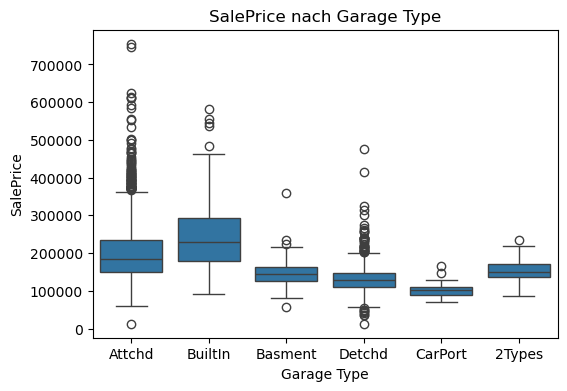

In [84]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Garage Type", y="SalePrice")
plt.title("SalePrice nach Garage Type")
plt.show()
#joa

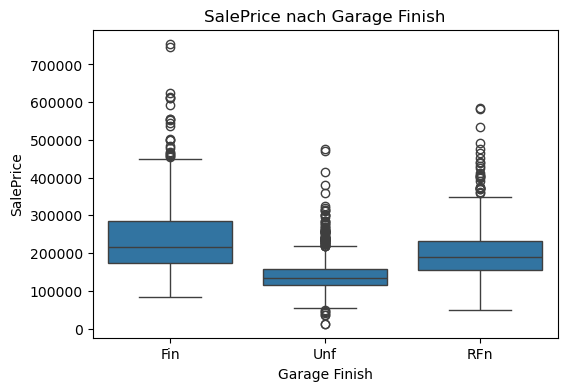

In [85]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Garage Finish", y="SalePrice")
plt.title("SalePrice nach Garage Finish")
plt.show()
#behalten

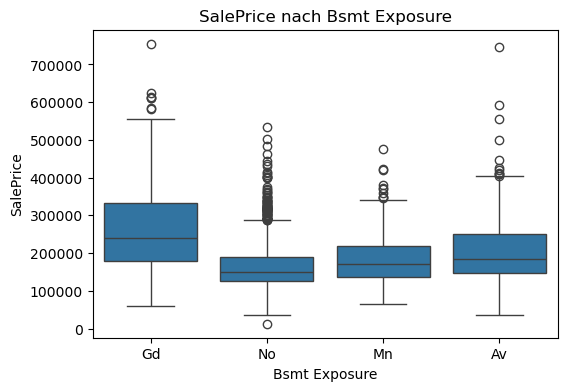

In [86]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Bsmt Exposure", y="SalePrice")
plt.title("SalePrice nach Bsmt Exposure")
plt.show()
#behalten

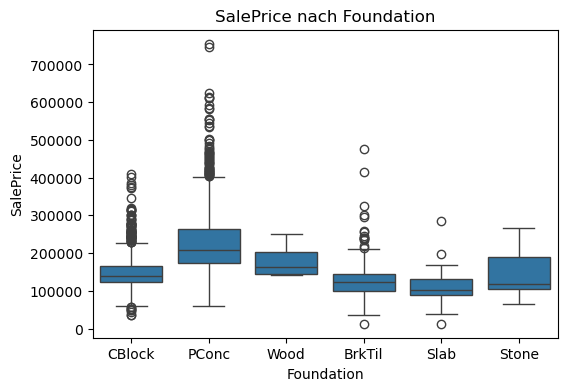

In [87]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Foundation", y="SalePrice")
plt.title("SalePrice nach Foundation")
plt.show()
#jo

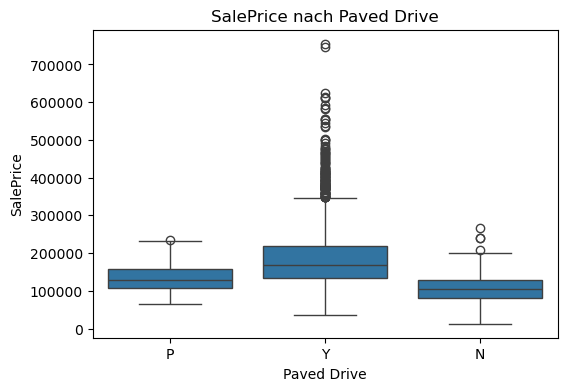

In [88]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Paved Drive", y="SalePrice")
plt.title("SalePrice nach Paved Drive")
plt.show()
#jo

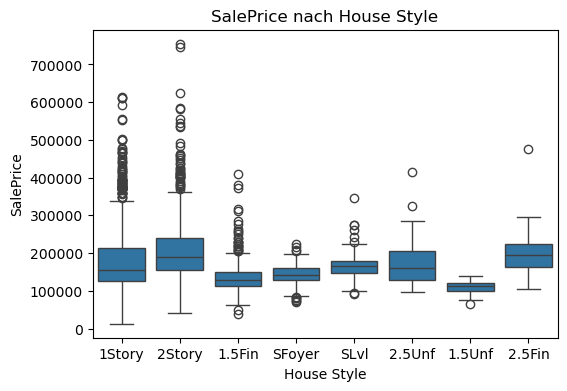

In [89]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="House Style", y="SalePrice")
plt.title("SalePrice nach House Style")
plt.show()
#jo

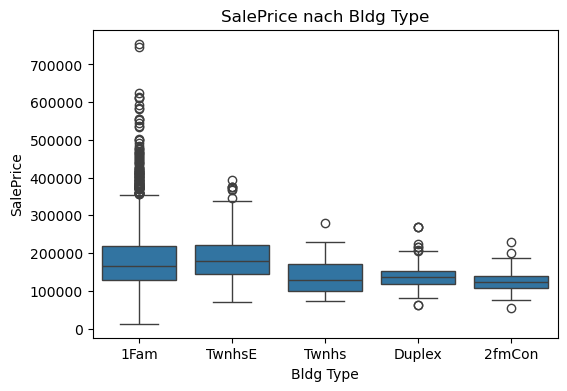

In [90]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Bldg Type", y="SalePrice")
plt.title("SalePrice nach Bldg Type")
plt.show()
#jo

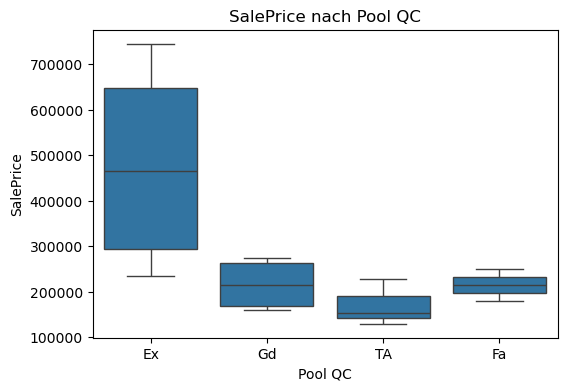

In [91]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Pool QC", y="SalePrice")
plt.title("SalePrice nach Pool QC")
plt.show()
#joa, wenige werte

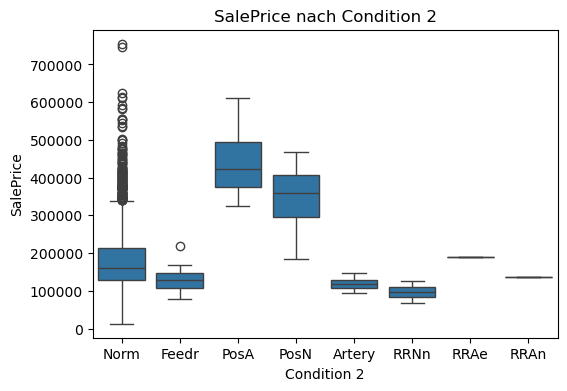

In [92]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Condition 2", y="SalePrice")
plt.title("SalePrice nach Condition 2")
plt.show()
#joa

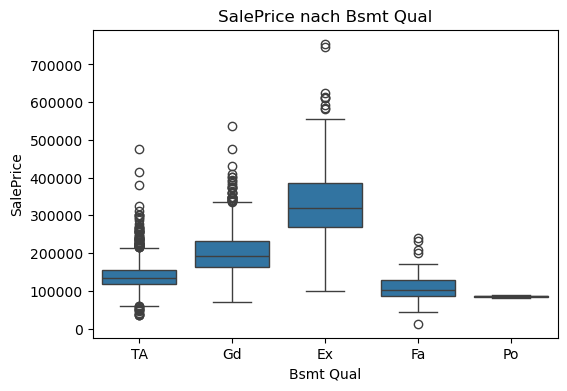

In [93]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Bsmt Qual", y="SalePrice")
plt.title("SalePrice nach Bsmt Qual")
plt.show()
#ja

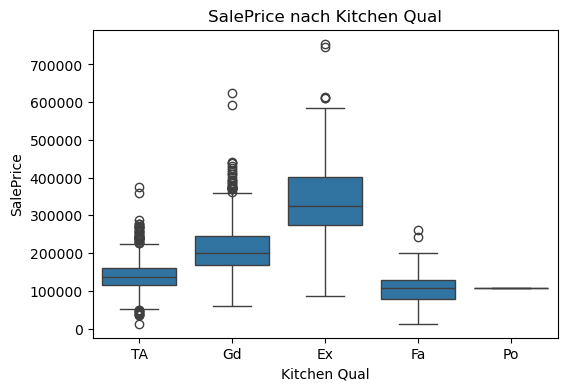

In [94]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Kitchen Qual", y="SalePrice")
plt.title("SalePrice nach Kitchen Qual")
plt.show()
#ja

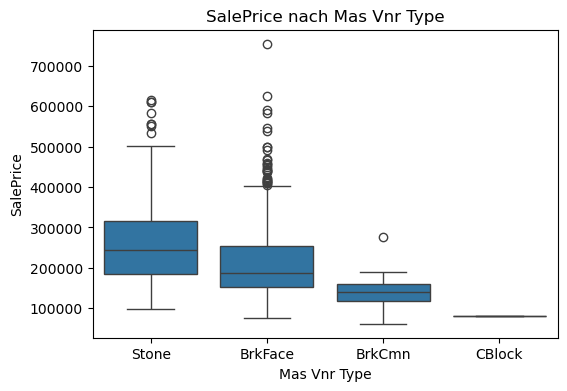

In [95]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Mas Vnr Type", y="SalePrice")
plt.title("SalePrice nach Mas Vnr Type")
plt.show()
#joa

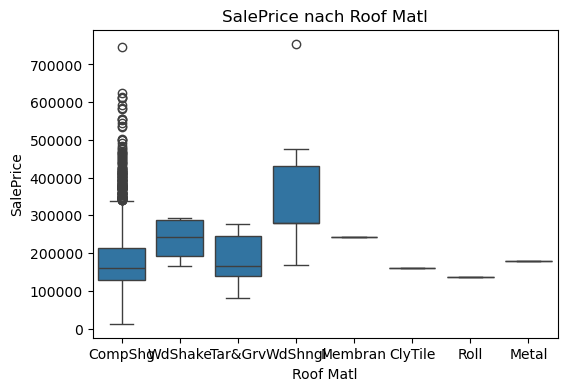

In [96]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Roof Matl", y="SalePrice")
plt.title("SalePrice nach Roof Matl")
plt.show()
#ne

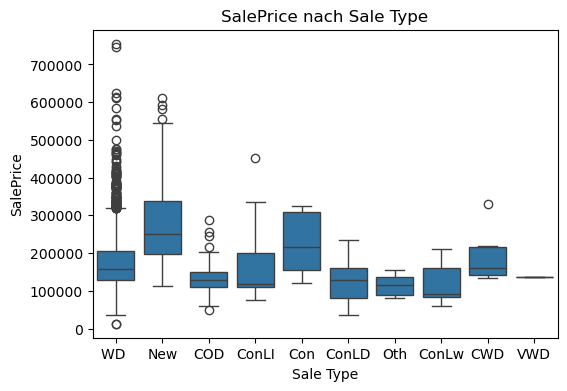

In [97]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Sale Type", y="SalePrice")
plt.title("SalePrice nach Sale Type")
plt.show()
#joa

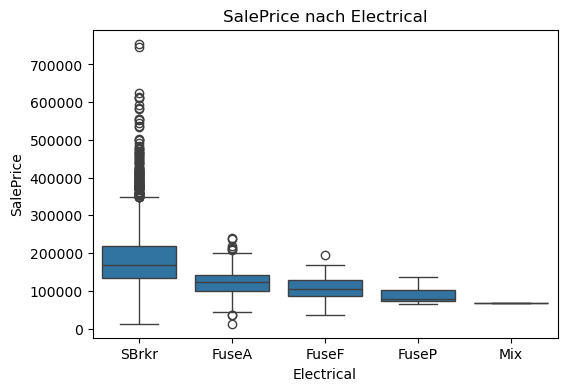

In [98]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Electrical", y="SalePrice")
plt.title("SalePrice nach Electrical")
plt.show()
#joa

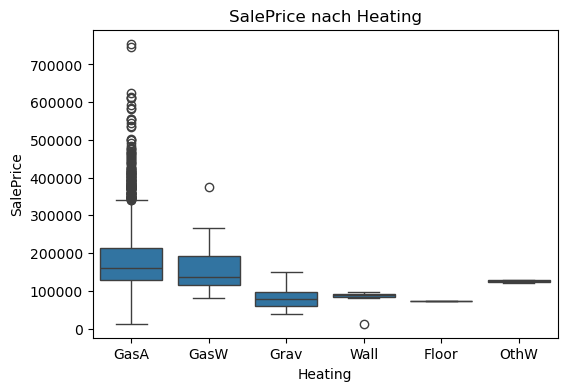

In [99]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Heating", y="SalePrice")
plt.title("SalePrice nach Heating")
plt.show()
#ne

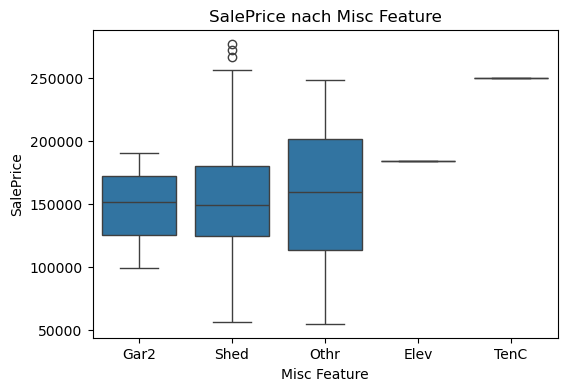

In [100]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="Misc Feature", y="SalePrice")
plt.title("SalePrice nach Misc Feature")
plt.show()
#ne

In [101]:
# object-Spalten mit niedriger Priorität löschen
df = df.drop(columns=[
    "Pool QC",
    "Condition 2",
    "Roof Matl",
    "Heating",
    "Misc Feature",
    "Electrical"
])

In [102]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 51 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MS Zoning       2930 non-null   object 
 1   Street          2930 non-null   object 
 2   Alley           198 non-null    object 
 3   Lot Shape       2930 non-null   object 
 4   Land Contour    2930 non-null   object 
 5   Utilities       2930 non-null   object 
 6   Lot Config      2930 non-null   object 
 7   Land Slope      2930 non-null   object 
 8   Neighborhood    2930 non-null   object 
 9   Condition 1     2930 non-null   object 
 10  Bldg Type       2930 non-null   object 
 11  House Style     2930 non-null   object 
 12  Overall Qual    2930 non-null   int64  
 13  Year Built      2930 non-null   int64  
 14  Year Remod/Add  2930 non-null   int64  
 15  Roof Style      2930 non-null   object 
 16  Exterior 1st    2930 non-null   object 
 17  Exterior 2nd    2930 non-null   o

In [103]:
from scipy.stats import f_oneway

# Beispiel für Central Air
groups = [group["SalePrice"].dropna().values for _, group in df.groupby("Central Air")]

f_stat, p_value = f_oneway(*groups)

print("F-Statistik:", f_stat)
print("p-Wert:", p_value)

F-Statistik: 220.26399438812342
p-Wert: 4.247467563542197e-48


In [105]:
#ersten 10 spalten mit prozentuale angabe der fehlenden werte
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(missing_percent.head(18))

Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Garage Finish      5.426621
Garage Yr Blt      5.426621
Garage Cond        5.426621
Garage Qual        5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
BsmtFin Type 1     2.730375
Bsmt Cond          2.730375
Bsmt Qual          2.730375
Mas Vnr Area       0.784983
Garage Area        0.034130
Garage Cars        0.034130
Total Bsmt SF      0.034130
dtype: float64


In [106]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Garage Finish      159
Garage Yr Blt      159
Garage Cond        159
Garage Qual        159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
BsmtFin Type 1      80
Bsmt Cond           80
Bsmt Qual           80
Mas Vnr Area        23
Garage Area          1
Garage Cars          1
Total Bsmt SF        1
TotRms AbvGrd        0
Sale Condition       0
dtype: int64


In [107]:
# kategoriale Spalten mit "None" füllen
cols_none = [
    "Alley",
    "Fence",
    "Mas Vnr Type",
    "Fireplace Qu",
    "Garage Finish",
    "Garage Cond",
    "Garage Qual",
    "Garage Type",
    "Bsmt Exposure",
    "BsmtFin Type 2",
    "BsmtFin Type 1",
    "Bsmt Cond",
    "Bsmt Qual"
]

for col in cols_none:
    df[col] = df[col].fillna("None")

In [108]:
# numerische fehlende Werte füllen
df["Mas Vnr Area"] = df["Mas Vnr Area"].fillna(0)
df["Garage Yr Blt"] = df["Garage Yr Blt"].fillna(df["Garage Yr Blt"].median())
df["Garage Area"] = df["Garage Area"].fillna(0)
df["Garage Cars"] = df["Garage Cars"].fillna(0)
df["Total Bsmt SF"] = df["Total Bsmt SF"].fillna(0)

In [109]:
print(df.isnull().sum().sort_values(ascending=False).head(20))

MS Zoning         0
Fireplace Qu      0
Total Bsmt SF     0
Heating QC        0
Central Air       0
1st Flr SF        0
Gr Liv Area       0
Full Bath         0
Kitchen Qual      0
TotRms AbvGrd     0
Functional        0
Fireplaces        0
Garage Type       0
BsmtFin Type 1    0
Garage Yr Blt     0
Garage Finish     0
Garage Cars       0
Garage Area       0
Garage Qual       0
Garage Cond       0
dtype: int64


In [110]:
print (df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 51 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   MS Zoning       2930 non-null   object 
 1   Street          2930 non-null   object 
 2   Alley           2930 non-null   object 
 3   Lot Shape       2930 non-null   object 
 4   Land Contour    2930 non-null   object 
 5   Utilities       2930 non-null   object 
 6   Lot Config      2930 non-null   object 
 7   Land Slope      2930 non-null   object 
 8   Neighborhood    2930 non-null   object 
 9   Condition 1     2930 non-null   object 
 10  Bldg Type       2930 non-null   object 
 11  House Style     2930 non-null   object 
 12  Overall Qual    2930 non-null   int64  
 13  Year Built      2930 non-null   int64  
 14  Year Remod/Add  2930 non-null   int64  
 15  Roof Style      2930 non-null   object 
 16  Exterior 1st    2930 non-null   object 
 17  Exterior 2nd    2930 non-null   o

In [111]:
# doppelte Zeilen prüfen
print(df.duplicated().sum())

1


In [112]:
df = df.drop_duplicates()

In [113]:
print(df.duplicated().sum())

0


In [114]:
# Datentypen anzeigen
print(df.dtypes)

MS Zoning          object
Street             object
Alley              object
Lot Shape          object
Land Contour       object
Utilities          object
Lot Config         object
Land Slope         object
Neighborhood       object
Condition 1        object
Bldg Type          object
House Style        object
Overall Qual        int64
Year Built          int64
Year Remod/Add      int64
Roof Style         object
Exterior 1st       object
Exterior 2nd       object
Mas Vnr Type       object
Mas Vnr Area      float64
Exter Qual         object
Exter Cond         object
Foundation         object
Bsmt Qual          object
Bsmt Cond          object
Bsmt Exposure      object
BsmtFin Type 1     object
BsmtFin Type 2     object
Total Bsmt SF     float64
Heating QC         object
Central Air        object
1st Flr SF          int64
Gr Liv Area         int64
Full Bath           int64
Kitchen Qual       object
TotRms AbvGrd       int64
Functional         object
Fireplaces          int64
Fireplace Qu

In [115]:
# object-Spalten in category umwandeln
object_cols = df.select_dtypes(include=['object']).columns

for col in object_cols:
    df[col] = df[col].astype('category')

print(df.dtypes)

MS Zoning         category
Street            category
Alley             category
Lot Shape         category
Land Contour      category
Utilities         category
Lot Config        category
Land Slope        category
Neighborhood      category
Condition 1       category
Bldg Type         category
House Style       category
Overall Qual         int64
Year Built           int64
Year Remod/Add       int64
Roof Style        category
Exterior 1st      category
Exterior 2nd      category
Mas Vnr Type      category
Mas Vnr Area       float64
Exter Qual        category
Exter Cond        category
Foundation        category
Bsmt Qual         category
Bsmt Cond         category
Bsmt Exposure     category
BsmtFin Type 1    category
BsmtFin Type 2    category
Total Bsmt SF      float64
Heating QC        category
Central Air       category
1st Flr SF           int64
Gr Liv Area          int64
Full Bath            int64
Kitchen Qual      category
TotRms AbvGrd        int64
Functional        category
F

In [116]:
#finale kontrolle
print("Dimensionen:")
print(df.shape)

print("\nFehlende Werte:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nDatentypen:")
print(df.dtypes)

print("\nErste Zeilen:")
print(df.head())

Dimensionen:
(2929, 51)

Fehlende Werte:
MS Zoning        0
Fireplace Qu     0
Total Bsmt SF    0
Heating QC       0
Central Air      0
1st Flr SF       0
Gr Liv Area      0
Full Bath        0
Kitchen Qual     0
TotRms AbvGrd    0
dtype: int64

Datentypen:
MS Zoning         category
Street            category
Alley             category
Lot Shape         category
Land Contour      category
Utilities         category
Lot Config        category
Land Slope        category
Neighborhood      category
Condition 1       category
Bldg Type         category
House Style       category
Overall Qual         int64
Year Built           int64
Year Remod/Add       int64
Roof Style        category
Exterior 1st      category
Exterior 2nd      category
Mas Vnr Type      category
Mas Vnr Area       float64
Exter Qual        category
Exter Cond        category
Foundation        category
Bsmt Qual         category
Bsmt Cond         category
Bsmt Exposure     category
BsmtFin Type 1    category
BsmtFin Type 2

In [117]:
# bereinigten Datensatz speichern
df.to_csv("AmesHousing_sauber.csv", index=False)

print("Bereinigter Datensatz wurde gespeichert!")

Bereinigter Datensatz wurde gespeichert!


In [118]:
# Zielspalte SalePrice genauer anschauen
print(df["SalePrice"].describe())

count      2929.000000
mean     180765.775350
std       79883.509011
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


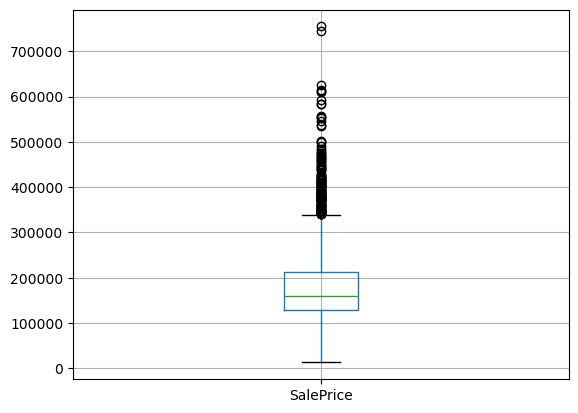

In [119]:
df.boxplot(column='SalePrice')
plt.show()

In [120]:
# Ausreißer in SalePrice mit der IQR-Methode prüfen
Q1 = df['SalePrice'].quantile(0.25)
Q3 = df['SalePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['SalePrice'] < lower_bound) | (df['SalePrice'] > upper_bound)]

print(outliers[['SalePrice']])
print("Anzahl Ausreißer:", len(outliers))

      SalePrice
15       538000
17       394432
36       376162
38       395192
44       611657
...         ...
2666     475000
2737     415000
2883     375000
2901     369900
2902     359900

[137 rows x 1 columns]
Anzahl Ausreißer: 137


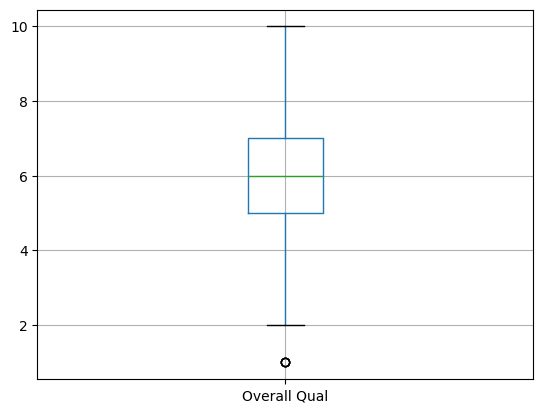

In [121]:
df.boxplot(column='Overall Qual')
plt.show()

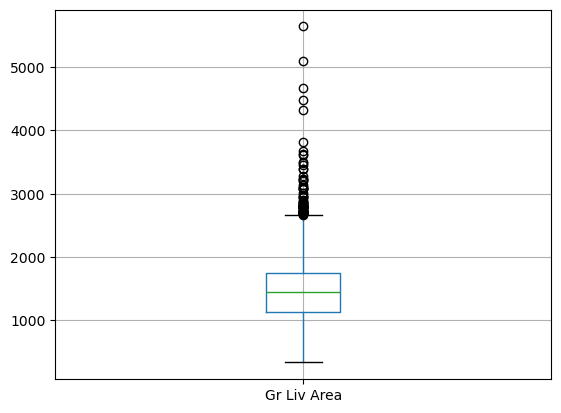

In [122]:
df.boxplot(column='Gr Liv Area')
plt.show()

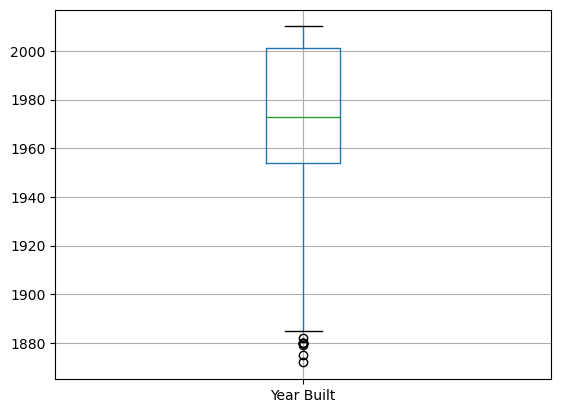

In [123]:
df.boxplot(column='Year Built')
plt.show()

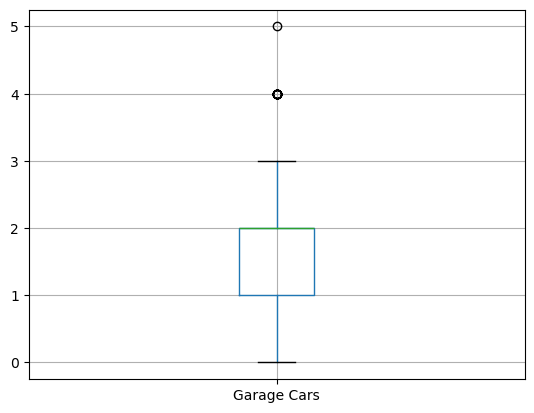

In [124]:
df.boxplot(column='Garage Cars')
plt.show()

In [93]:
# bereinigten Datensatz speichern
#df.to_csv("AmesHousing_cleaned.csv", index=False)
#print("Bereinigter Datensatz wurde gespeichert.")

Bereinigter Datensatz wurde gespeichert.
